<a href="https://colab.research.google.com/github/hasan2733/artificial-intelligence/blob/main/Notebooks/ML/XgbBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Great! Since you now understand Decision Trees, XGBoost becomes much easier because XGBoost is simply many decision trees working together.

Let's go through the complete workflow.

XGBoost Workflow
Training Data
         
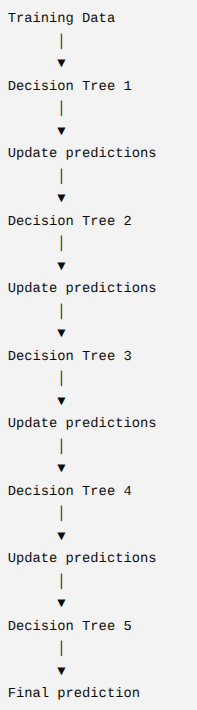



Final Prediction = Sum of all tree outputs

**Step 1: Training Dataset**

Suppose we have

Hours Studied	Actual Score
1	50
2	60
3	70
4	80


Our goal is to predict the exam score.

**Step 2: Initial Prediction**

Unlike a normal Decision Tree, XGBoost does not build a tree immediately.

First it predicts the same value for everyone.

Usually

Initial Prediction=Mean(Target)

Mean

4

50+60+70+80 = 65

So

Hours	Prediction
1	65
2	65
3	65
4	65

**Step 3: Calculate Error**

Residual

Residual=Actual−Prediction
Actual	Prediction	Residual
50	65	-15
60	65	-5
70	65	5
80	65	15

These residuals tell us how wrong the model is.

**Step 4: Build Decision Tree 1**

Now XGBoost builds a Decision Tree.

But notice something important.

The tree is NOT predicting exam scores.

The tree predicts the errors (or, more precisely in XGBoost, the gradients).

The tree might look like

Hours < 2.5 ?
      /      \
   Yes        No
  -10         +10

This means

Students studying less than 2.5 hours need about −10 correction.

Students studying more than 2.5 hours need about +10 correction.

**Step 5: Update Prediction**

Suppose

Learning Rate

η=0.5

Update rule

New Prediction=Old Prediction+η×Tree Output

For first student

65+0.5(−10)=60

For fourth student

65+0.5(10)=70

New predictions

Hours	Prediction
1	60
2	60
3	70
4	70

Notice the predictions have moved closer to the actual values.

**Step 6: Calculate New Errors**
Actual	Prediction	Residual
50	60	-10
60	60	0
70	70	0
80	70	10

The errors are now smaller.

**Step 7: Build Tree 2**

Tree 2 learns these remaining errors.

It might predict

Hours=1  → -10

Hours=2  → 0

Hours=3  → 0

Hours=4  → +10

Notice that Tree 2 is not starting from scratch. It only tries to fix what Tree 1 couldn't.

**Step 8: Update Again**

Hour 1

60+0.5(−10)=55

Hour 4

70+0.5(10)=75

Predictions become

Hours	Prediction
1	55
2	60
3	70
4	75

Now they're even closer to the real scores.

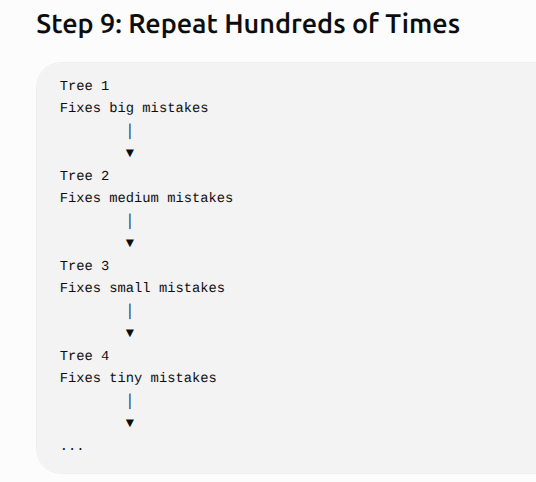

Each tree makes a small improvement instead of trying to solve the whole problem.

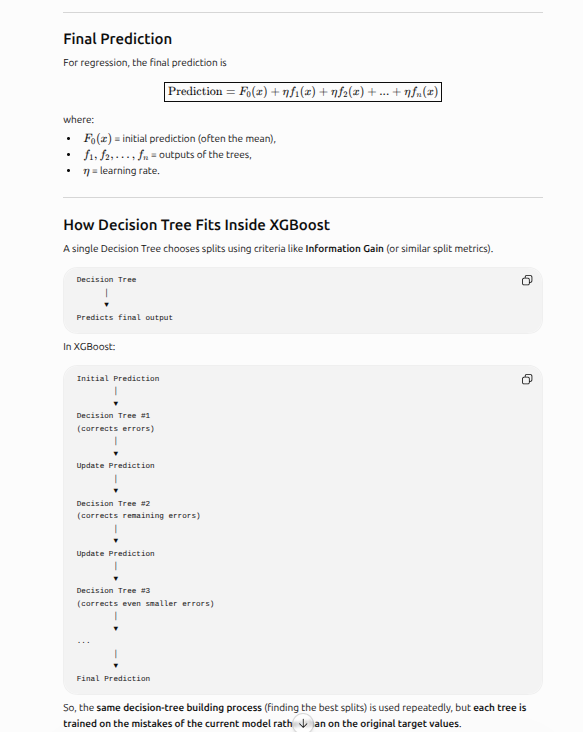

So, the same decision-tree building process (finding the best splits) is used repeatedly, but each tree is trained on the mistakes of the current model rather than on the original target values.

The biggest conceptual difference
Decision Tree	XGBoost
Builds one tree.	Builds many trees sequentially.

Predicts the target directly.	Starts with a simple prediction, then each new tree predicts corrections (gradients/residuals).

Stops after one tree.	Keeps adding trees until the error is sufficiently small or a set number of trees is reached.

Final prediction comes from one tree.	Final prediction is the sum of the initial prediction and the contributions of all trees.

**In one sentence: A Decision Tree tries to solve the entire problem in one model, while XGBoost solves it by repeatedly asking, "What's still wrong with my current prediction?" and building a new tree to fix those remaining mistakes.**



Exactly! That's the main idea of XGBoost.

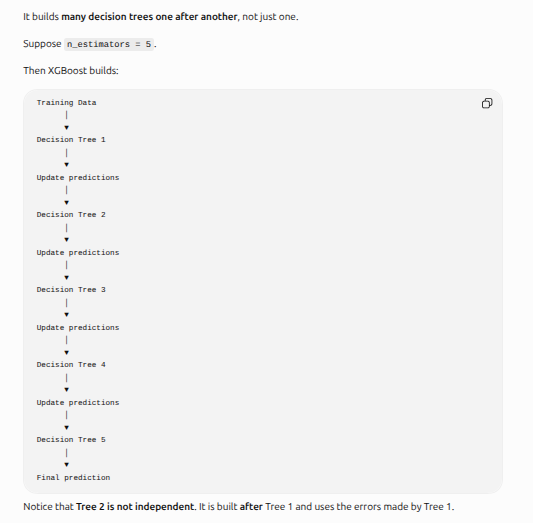

Notice that Tree 2 is not independent. It is built after Tree 1 and uses the errors made by Tree 1.

Think of it like an exam

Suppose your teacher grades your paper.

First attempt
Score = 60/100

The teacher says:

"You made mistakes in Algebra."

So you study Algebra.

Second attempt

Now your score becomes

80/100

The teacher says:

"Good. But Geometry still has mistakes."

So you study Geometry.

Third attempt
92/100

Teacher says:

"Only a few calculation mistakes remain."

You fix those.

Final
99/100

Each attempt corrects the previous mistakes.

That is exactly how XGBoost works.

What does each tree learn?

Suppose the actual values are

Sample	Actual
A	50
B	60
C	70
Initial prediction
65
65
65

Errors

-15
-5
+5
Tree 1 learns
-10
-5
+10

Predictions become

60
62.5
70

Now calculate new errors.

-10
-2.5
0
Tree 2 learns
-5
-2
0

Predictions improve again.

Then Tree 3 learns the remaining small errors.

Then Tree 4...

Then Tree 5...

Does every tree use the same dataset?

Yes, every tree sees the same training samples, but not the same target.

Imagine the original data is:

Student	Hours	Actual Score
A	1	50
B	2	60
C	3	70
Tree 1: uses the original data and learns the initial corrections.
Tree 2: uses the same students and features (Hours), but now the "target" is the remaining error (or more precisely, the gradient) after Tree 1.
Tree 3: again uses the same data, but learns the errors left after Tree 2.

So the features never change, but the values the trees are trying to predict become smaller as the model improves.

**One sentence to remember**

**XGBoost repeatedly builds small decision trees. Each new tree learns from the mistakes of all the previous trees and adds a correction to make the predictions more accurate.**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBClassifier
from tensorflow.keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

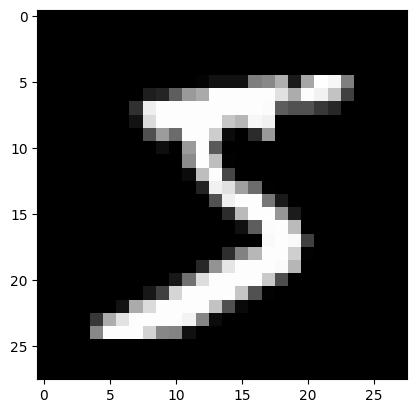

In [4]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [5]:
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
x_train.shape

(60000, 784)

In [6]:
model = XGBClassifier()
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [7]:
model.score(x_test, y_test)

0.9784